## Ries data

[Ries et. al.](https://doi.org/10.6094/UNIFR/151460) data contains data of a experimental campaign on 21 experimental sites with 6 distinct experiments on each site.
The data is published in an institutional repository, without table descriptive metadata interpreted by this repository.
Metadata for each table column is contained within the data *.tsv files in comment rows, which were extracted and parsed to fricitonless descriptors.
Concepts from controlled vacabularies were assigned to the fricitonless descriptor from a user defined mapping.

In [1]:
from dataset_loader import *
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
RIES = load_sp_datapackage({"sourcedir": "example_datasets/RIES/"}, 'RIES')
#sorted(get_dataset_concepts(TUBAF, vocab = optio))
RIES

{'resources': [{'name': '1_site_data',
                'type': 'table',
                'path': 'tables/1_site_data.csv',
                'scheme': 'file',
                'format': 'csv',
                'mediatype': 'text/csv',
                'encoding': 'utf-8',
                'schema': {'fields': [{'name': 'Site_number',
                                       'type': 'integer',
                                       'description': ' ID number of '
                                                      'experiment location ',
                                       'unit': '-',
                                       'concept': ''},
                                      {'name': 'Site_name',
                                       'type': 'string',
                                       'description': ' Name of experiment '
                                                      'location ',
                                       'unit': '-',
                                       'conc

In [3]:
#RIES.resources[2].schema.primary_key += ['Experiment_number']
RIES.resources[2].schema.primary_key
RIES.validate()

{'valid': True,
 'stats': {'tasks': 3, 'errors': 0, 'warnings': 0, 'seconds': 11.064},
 'warnings': [],
 'errors': [],
 'tasks': [{'name': '1_site_data',
            'type': 'table',
            'valid': True,
            'place': 'tables/1_site_data.csv',
            'labels': ['Site_number',
                       'Site_name',
                       'Elevation',
                       'Slope',
                       'Slope_aspect',
                       'Land_use',
                       'Vegetation',
                       'Vegetation_height',
                       'Plant_coverage',
                       'Geology_GUEK300',
                       'Sand_10cm',
                       'Silt_10cm',
                       'Clay_10cm',
                       'Sand_30cm',
                       'Silt_30cm',
                       'Clay_30cm',
                       'Sand_50cm',
                       'Silt_50cm',
                       'Clay_50cm',
                       'Bulk_density_10

Text(0.5, 0, 'Experiment No')

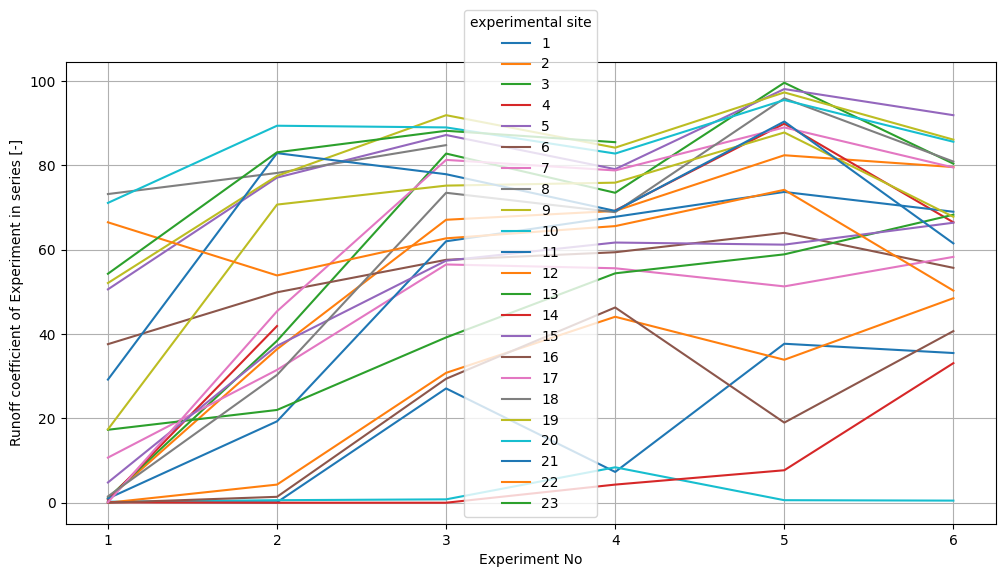

In [4]:
# select mean overland flow Runoff coefficients from RIES data
a = view_sp_resource(RIES.resources[1], fields = ['RC_OF_mean_selected'])
# without .open() and .close() the first call gets only the last experiments - for whatever frictionless reason
a.open()
a.close()

# convert this to pandas and draw a figure
b = a.to_pandas()

fig = plt.figure(figsize=(12, 6))
ax1 = fig.add_subplot(111)
for x in b.index.get_level_values('Site_number').unique():
    site_data = b.xs(x, level="Site_number")
    #site_data = b[b.index.get_level_values("Site_number") == x].reset_index()
    ax1.plot(site_data, label = x)
    #ax1.plot(site_data.Experiment_number, site_data.RC_OF_mean_selected, label=x)
ax1.grid()
ax1.legend(title = "experimental site")
ax1.set_ylabel("Runoff coefficient of Experiment in series [-]")
ax1.set_xlabel("Experiment No")

In [5]:
a_time = view_sp_resource(RIES.resources[2],
                          fields = ['Experiment_number', 'P_mean_selected', 'Q_OF_mean_selected'],
                          #row_filters = ['P_mean_selected > 1.5']
                         )
# without .open() and .close() the first call gets only the last experiments - for whatever frictionless reason
a_time.open()
a_time.close()
print(a_time.validate().valid)
a_time

False


{'name': '3_experiment_time_series',
 'type': 'table',
 'data': [],
 'scheme': '',
 'format': 'inline',
 'mediatype': 'text/csv',
 'extrapaths': [],
 'schema': {'fields': [{'name': 'Date_time',
                        'type': 'datetime',
                        'description': ' Date and time in Central European '
                                       'Summer Time (CEST) = UTC +2 hours ',
                        'format': '%Y-%m-%d %H:%M',
                        'unit': 'yyyy-mm-ddhh',
                        'concept': ''},
                       {'name': 'Site_number',
                        'type': 'integer',
                        'description': ' ID number of experiment location ',
                        'unit': '1to23',
                        'concept': ''},
                       {'name': 'Experiment_number',
                        'type': 'integer',
                        'description': ' ID number of experiment ',
                        'unit': '1to6',
                

In [6]:
a_time.open()
a_time.close()
b_time = a_time.to_pandas()
#b_time = b_time.reorder_levels(['Date_time', 'Site_number','Experiment_number']).sort_index()
b_time.head()

,,,P_mean_selected,Q_OF_mean_selected
Date_time,Site_number,Experiment_number,,
2016-08-16 01:40:00,1,NaN,0.0,0.0
2016-08-16 01:41:00,1,NaN,0.0,0.0
2016-08-16 01:42:00,1,NaN,0.0,0.0
2016-08-16 01:43:00,1,NaN,0.0,0.0
2016-08-16 01:44:00,1,NaN,0.0,0.0


Text(0.5, 0, 'Date')

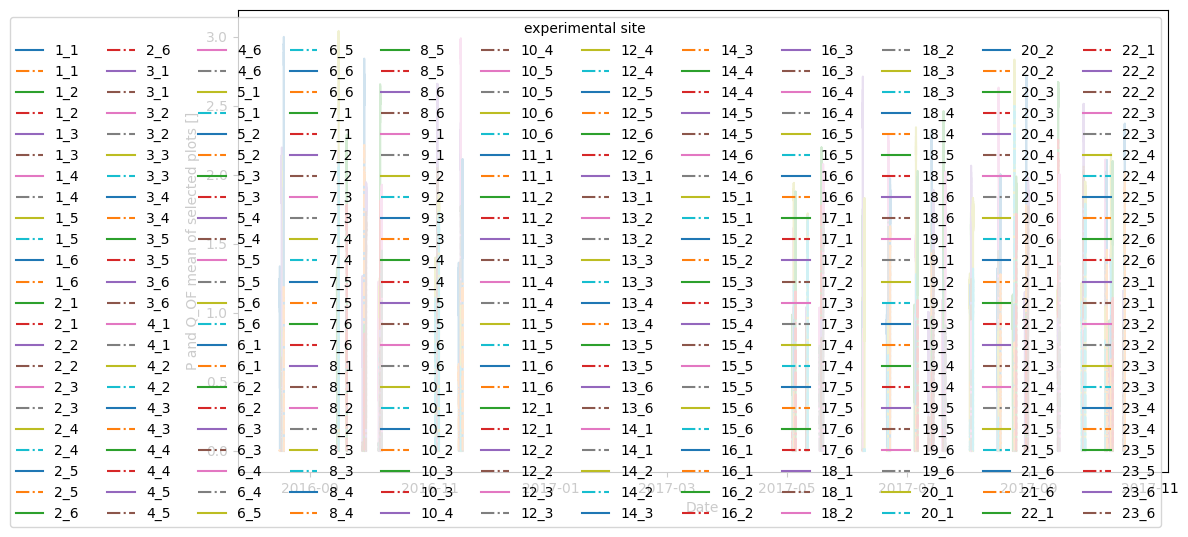

In [7]:
fig = plt.figure(figsize=(12, 6))
ax1 = fig.add_subplot(111)
for x in b_time.index.levels[1]:
    plot_data = b_time.xs(x, level="Site_number")
    for y in b_time.index.levels[2]:
        site_data = plot_data.xs(y, level="Experiment_number")
        #site_data = b[b.index.get_level_values("Site_number") == x].reset_index()
        ax1.plot(site_data.index, site_data.P_mean_selected, label = str(x)+"_"+str(y))
        ax1.plot(site_data.index, site_data.Q_OF_mean_selected, label = str(x)+"_"+str(y), linestyle = 'dashdot')
#ax1.grid()
ax1.legend(title = "experimental site", ncol = 12)
ax1.set_ylabel("P and Q_OF mean of selected plots []")
ax1.set_xlabel("Date")

<Axes: xlabel='Date_time'>

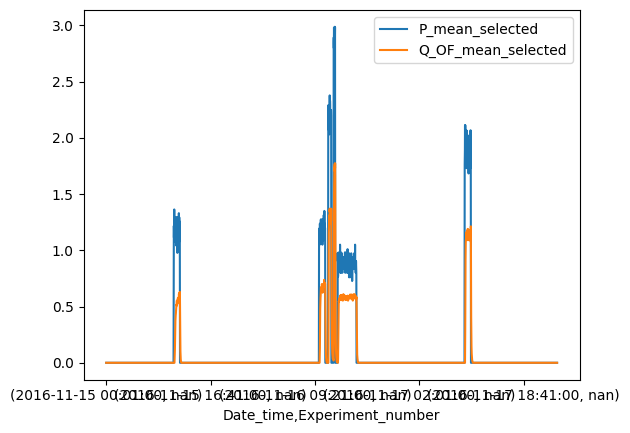

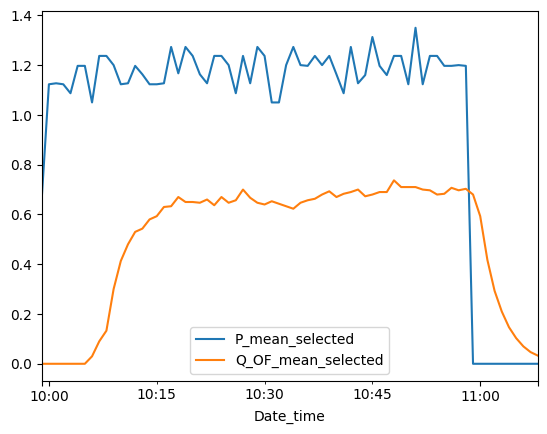

In [8]:
b_slice = b_time.xs(6, level="Site_number")
b_slice.plot()

c_slice = b_slice.xs(2, level="Experiment_number")
c_slice.plot()

<Axes: xlabel='Date_time'>

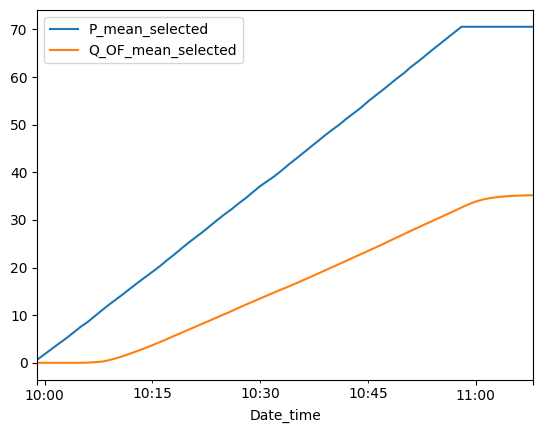

In [9]:
d_slice= c_slice.cumsum()
d_slice.plot()

0.4987669718529436

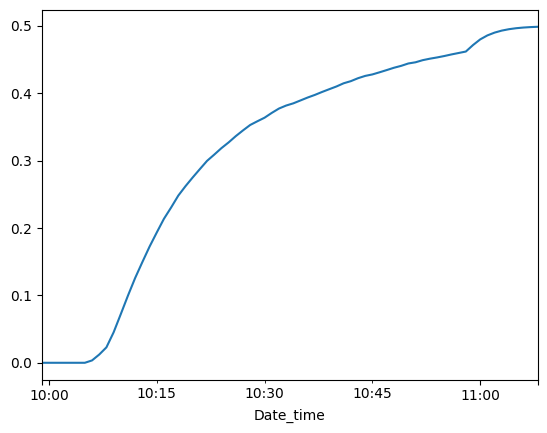

In [10]:
(d_slice.Q_OF_mean_selected/d_slice.P_mean_selected).plot()
(d_slice.Q_OF_mean_selected/d_slice.P_mean_selected).max()

In [11]:
agg = b_time.pivot_table(values=["P_mean_selected","Q_OF_mean_selected"], columns=['Site_number','Experiment_number'], aggfunc='sum', dropna=True)
agg = agg.T
agg['RC'] = round(agg.Q_OF_mean_selected/ agg.P_mean_selected * 100, 1)
agg

P_mean_selected  Q_OF_mean_selected    RC
Site_number Experiment_number                                           
1           1.0                         66.702               0.114   0.2
            2.0                        132.738               0.117   0.1
            3.0                        118.112              32.044  27.1
            4.0                         60.483               4.430   7.3
            5.0                         60.251              22.724  37.7
...                                        ...                 ...   ...
23          2.0                         61.270              50.930  83.1
            3.0                         45.980              40.550  88.2
            4.0                         33.271              28.454  85.5
            5.0                          0.000               0.000   NaN
            6.0                          0.000               0.000   NaN

[138 rows x 3 columns]

In [12]:
agg.RC.values

array([ 0.2,  0.1, 27.1,  7.3, 37.7, 35.5,  0.9, 36.4, 67.1, 69.2, 82.4,
       79.6,  1.1, 38.4, 82.8, 73.5, 99.6, 80.4,  0.7, 41.9,  nan, 69.3,
       89.9, 66.5, 50.6, 77.1, 87.2, 79.1, 98.1, 91.9, 37.6, 49.9, 57.6,
       59.4, 64. , 55.7, 10.7, 31.5, 56.5, 55.6, 51.3, 58.3, 73.2, 78.2,
       84.8,  nan,  nan,  nan, 52.1, 77.5, 91.9, 84.2, 97.3, 86.1,  0.2,
        0.6,  0.8,  8.4,  0.6,  0.5,  1. , 19.3, 62. , 67.8, 73.7, 69. ,
        0. ,  4.3, 30.8, 44.1, 33.9, 48.5, 17.3, 22. , 39.2, 54.4, 58.9,
       68.3,  0.1,  0. ,  0. ,  4.3,  7.7, 33.1,  4.8, 37.2, 57.4, 61.7,
       61.2, 66.4,  0. ,  1.4, 29.4, 46.3, 19. , 40.7,  0.1, 45.4, 81.3,
       78.8, 89. , 79.5,  1.5, 30.3, 73.5, 68.9, 95.9, 80.9, 17.4, 70.7,
       75.2, 75.9, 87.8, 67.8, 71.1, 89.4, 89. , 82.8, 95.5, 85.6, 29.2,
       82.9, 77.9, 69.2, 90.4, 61.5, 66.5, 53.9, 62.7, 65.6, 74.2, 50.3,
       54.3, 83.1, 88.2, 85.5,  nan,  nan])

C:\Users\Jonas.Lenz\AppData\Local\Temp\ipykernel_3392\3657919181.py:2: RuntimeWarning: invalid value encountered in divide
  plt.plot(agg.RC.values/b.RC_OF_mean_selected.values)


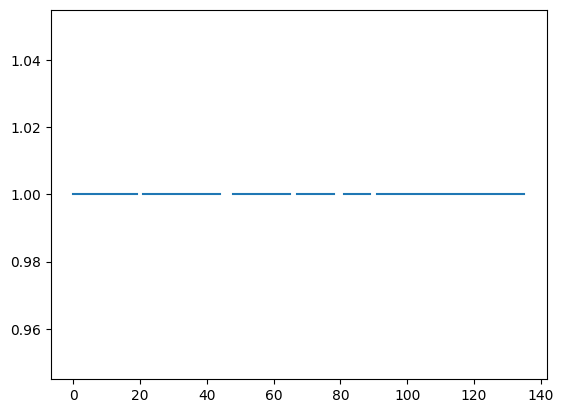

In [14]:
# All recalculated RC values divided by given values equal 1, so recalculation was successfull 
plt.plot(agg.RC.values/b.RC_OF_mean_selected.values)
#print(agg.RC.values == b.RC_OF_mean_selected.values)
#print(agg.RC.values)
#print(b.RC_OF_mean_selected.values)

In [ ]:
TUBAF = load_sp_datapackage({"sourcedir": "catalogue/temp_1/"})
multitable = load_sp_datapackage({"sourcedir": "catalogue/temp_2/"})
Ries = load_sp_datapackage({"sourcedir": "catalogue/temp_4/"})
view_sp_resource(TUBAF.resources[0], fields = ['SigP'], row_filters = ['SigP >9', 'SigP < 12']).to_pandas()

get_dataset_concepts(TUBAF)
get_sp_data(TUBAF, fielddefinition=[{'name': 'SigP'}])
view = merge_foreign_keys(
    get_sp_data(
        TUBAF,
        fielddefinition=[
            {'name': 'SigP',
             'row_filters': ['No == "8"']
             },
            {'unit': 'g/l',
             'row_filters': ['not sedconc == None', 'No == "8"']
             }
            ]
        )
    )

view = get_sp_data(
    TUBAF,
    fielddefinition=[
        {'name': 'SigP',
         'row_filters': ['SigP > 10']
         },
        {'unit': 'g/l',
         'row_filters': ['not sedconc == None and sedconc >=300']
         }
        ]
    )


view = merge_foreign_keys(
    get_sp_data(
        TUBAF,
        fielddefinition=[
            {'name': 'SigP',
             'row_filters': ['No == "8"']
             },
            {'unit': 'g/l',
             'row_filters': ['not sedconc == None', 'No == "8"']
             }
            ]
        )
    )

try:
    view.extract()
except:
    view.extract()

# model requirements can be defined by row constraints
#from frictionless import validate, checks, transform
#validate(TUBAF.resources[0],
#         checks=[
#             checks.row_constraint(formula="fSi + mSi + cSi == SILT"),
#             checks.row_constraint(formula="fSa + mSa + cSa == SAND"),
#             checks.row_constraint(formula="SILT + SAND + CLAY == 100")
#             ]
#         )
TUBAF.resources[1].to_pandas().head()